Best objective: 2769 (0.15933)
Objective bound: 2797
Minimum objective: 2769
Cache sizes - Greedy: 388313, Lickety: 7987, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 1 / 3 with 56 trees
Best objective: 2880 (0.165717)
Objective bound: 2909
Minimum objective: 2880
Cache sizes - Greedy: 461304, Lickety: 10594, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 2 / 3 with 132 trees
Best objective: 2805 (0.161402)
Objective bound: 2833
Minimum objective: 2805
Cache sizes - Greedy: 391136, Lickety: 8052, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 3 / 3 with 80 trees

Rashomon Importance Distribution
--------------------------------
elapsed seconds: 26.25


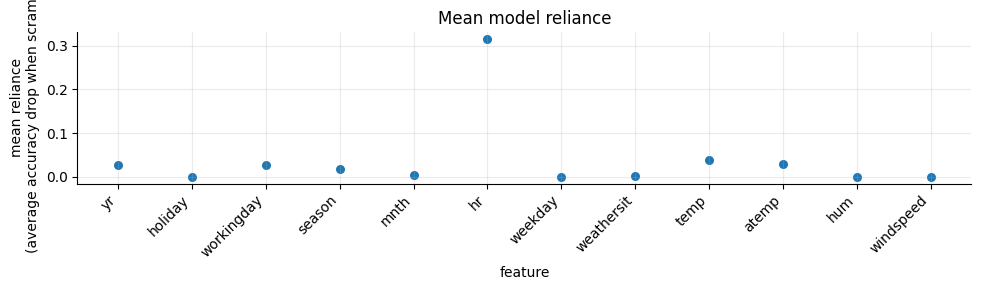

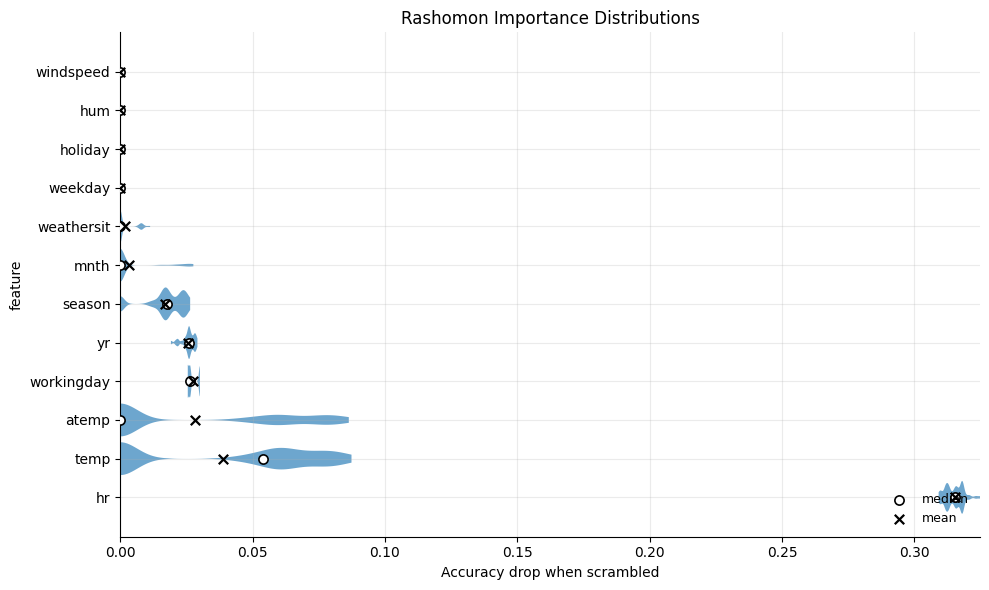

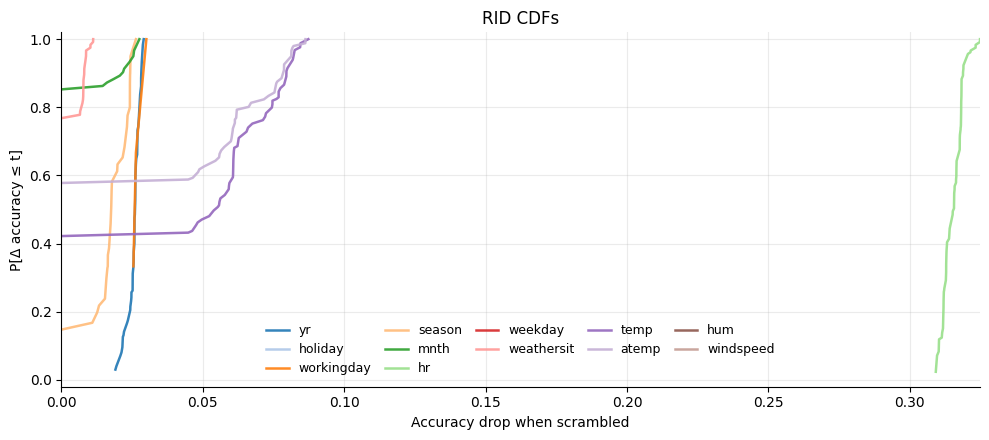

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arborenum import ArborEnum

df = pd.read_csv("bike_processed.csv").sample(
    frac=1.0,
    replace=True,
    random_state=0,
).reset_index(drop=True)

y = df.pop("label").to_numpy(dtype=np.int32)
X = df

model = ArborEnum()

start = time.perf_counter()

rid_result = model.compute_rid(
    X,
    y,
    proxy_mode="hybrid",
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    n_boot=3,
    n_scramble_evals=5,
)

elapsed = time.perf_counter() - start

print()
print("Rashomon Importance Distribution")
print("--------------------------------")
print("elapsed seconds:", f"{elapsed:.2f}")

model.rid_plot_mean(
    title="Mean model reliance",
    show=True,
)

model.rid_plot_violin(
    title="Rashomon Importance Distributions",
    show=True,
)

model.rid_plot_cdfs(
    title="RID CDFs",
    show=True,
)

plt.show()